<div align="center">



# **Análisis y Procesamiento de Señales**

## **Trabajo Semanal 1: Síntesis y operaciones de señales**



</div>

<br>
<br>
<br>
<br>

**Alumno:** Germán Fiore  
**Especialidad:** Ingeniería Biomédica  
**Fecha:** 03/09/2026  

---


### **Introducción**
El procesamiento digital de señales se basa en la transición del dominio analógico (continuo en tiempo y amplitud) al dominio digital (discreto en tiempo y cuantizado en amplitud). De acuerdo con el Teorema de Muestreo de Nyquist-Shannon, para garantizar la reconstrucción perfecta de una señal continua de banda acotada sin pérdida de información ni distorsión por aliasing (solapamiento espectral), la frecuencia de muestreo $f_s$ debe ser estrictamente mayor al doble de la frecuencia máxima componente de la señal analógica $f_{\text{max}}$: $$f_s > 2 f_{\text{max}}$$

Una vez muestreada, la señal se representa matemáticamente como una secuencia temporal discreta $x[n]$, donde el índice entero $n$ identifica de manera unívoca a cada muestra espaciada por un período de muestreo constante $T_s = 1/f_s$.Para analizar las componentes espectrales de una secuencia de longitud finita $N$, se utiliza la Transformada Discreta de Fourier (DFT), que discretiza el espectro continuo de la señal en $N$ canales o bins de frecuencia localizados en $f_k = k \frac{f_s}{N}$. Computacionalmente, la DFT se implementa mediante el algoritmo de Transformada Rápida de Fourier (FFT), el cual optimiza el costo algorítmico reduciendo la complejidad de $\mathcal{O}(N^2)$ a $\mathcal{O}(N \log N)$. Por otra parte, un concepto fundamental es la conservación de la potencia. El Teorema de Parseval nos asegura que la energía o potencia media de una señal es la misma sin importar si la calculamos en el dominio del tiempo o de la frecuencia. $$P_{\text{tiempo}} = \frac{1}{N} \sum_{n=0}^{N-1} |x[n]|^2 = \frac{1}{N^2} \sum_{k=0}^{N-1} |X[k]|^2 = P_{\text{frecuencia}}$$ 

### **Objetivos**
Sintetizar numéricamente señales determinísticas (senoidal pura y desfasada, pulso rectangular simétrico) controlando la frecuencia fundamental $f_0 = 2\text{ kHz}$, la fase inicial $\varphi$, y la potencia media $P_x$ calculando de forma analítica sus amplitudes. Generar procesos aleatorios (ruido blanco) con distribuciones probabilísticas normal (gaussiana) y uniforme, garantizando que tengan valor medio nulo (DC = 0 V) y una potencia controlada de 0.1 W. Calcular y graficar el espectro unilateral de magnitud de cada una de estas 5 señales usando el algoritmo de la FFT.

### **Codigo Completo**

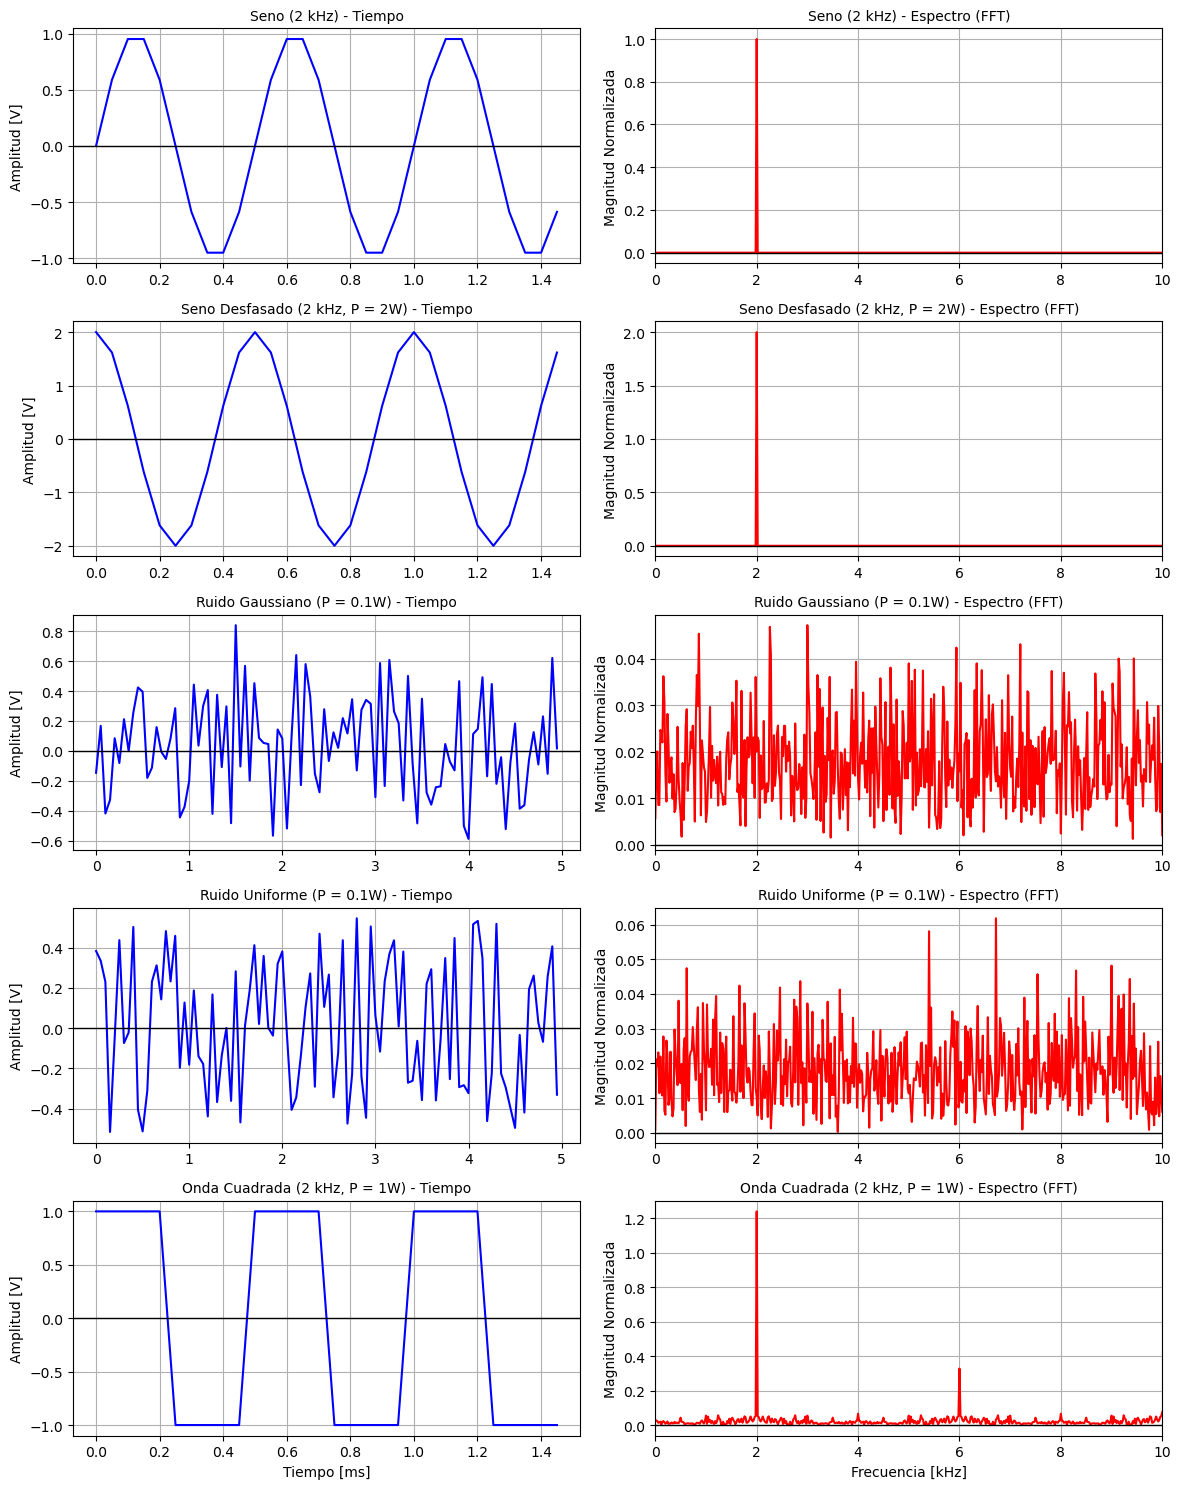

In [5]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt


# PARÁMETROS GENERALES

N = 1000          # Número de muestras 
f0 = 2000         # Frecuencia de las señales (2 kHz)

# Elegimos fs = 20 kHz para cumplir al menos 10 puntos por período
# (fs / f0 = 20000 / 2000 = exactamente 10 puntos por ciclo)
fs = 20000        
t = np.arange(N) / fs


# SÍNTESIS DE LAS 5 SEÑALES


# Señal 1: Senoidal de 2 kHz (Amplitud de 1 V)
x1 = np.sin(2 * np.pi * f0 * t)

# Señal 2: Seno desfasado pi/2 con potencia media de 2W y Amplitud A = 2 V
x2 = 2 * np.sin(2 * np.pi * f0 * t + np.pi / 2)

# Señal 3: Ruido normalmente distribuido (Gaussiano), DC = 0V, Varianza = 0.1 W
# Para el ruido, Potencia = Varianza (sigma^2). La desviación estándar es sqrt(0.1)
std_gauss = np.sqrt(0.1)
x3 = np.random.normal(0, std_gauss, N)

# Señal 4: Ruido uniformemente distribuido, DC = 0V, Varianza = 0.1 W
# Para distribución uniforme en [-b, b], Varianza = b^2 / 3 = 0.1 -> b = sqrt(0.3)
limite_b = np.sqrt(0.3)
x4 = np.random.uniform(-limite_b, limite_b, N)

# Señal 5: Pulso rectangular (onda cuadrada) de 2 kHz, Potencia = 1 W, Ciclo de actividad = 50%
# Potencia = A^2 = 1W -> Amplitud = 1 V
x5 = signal.square(2 * np.pi * f0 * t, duty=0.5)

# Guardamos las señales para graficar
seniales = [
    {"nombre": "Seno (2 kHz)", "datos": x1},
    {"nombre": "Seno Desfasado (2 kHz, P = 2W)", "datos": x2},
    {"nombre": "Ruido Gaussiano (P = 0.1W)", "datos": x3},
    {"nombre": "Ruido Uniforme (P = 0.1W)", "datos": x4},
    {"nombre": "Onda Cuadrada (2 kHz, P = 1W)", "datos": x5}
]


# GRAFICOS (Tiempo y Espectro FFT)

# Creamos una cuadrícula de 5 filas por 2 columnas
fig, axs = plt.subplots(5, 2, figsize=(12, 15))

for i, s in enumerate(seniales):
    x = s["datos"]
    
    # Columna 1: Dominio del Tiempo
    # Para ver la forma de las señales periódicas mostramos 30 muestras (3 ciclos).
    # Para los ruidos mostramos 100 muestras para que se aprecie la aleatoriedad.
    muestras_vis = 100 if "Ruido" in s["nombre"] else 30
    
    axs[i, 0].plot(t[:muestras_vis] * 1000, x[:muestras_vis], color="blue", linewidth=1.5)
    axs[i, 0].axhline(0, color="black", linewidth=1.0) # Eje X en y=0
    axs[i, 0].set_title(f"{s['nombre']} - Tiempo", fontsize=10)
    axs[i, 0].set_ylabel("Amplitud [V]")
    axs[i, 0].grid(True)
    
    # Columna 2: Dominio de la Frecuencia (FFT Unilateral)
    # Calculamos la FFT compleja y la normalizamos por N
    X_fft = np.fft.rfft(x) / N
    mag = np.abs(X_fft)
    
    # Multiplicamos por 2 los componentes (excepto continua) para recuperar la amplitud real
    mag[1:-1] = 2 * mag[1:-1]
    
    # Eje de frecuencias en Hz
    freqs = np.fft.rfftfreq(N, d=1/fs)
    
    axs[i, 1].plot(freqs / 1000, mag, color="red", linewidth=1.5)
    axs[i, 1].axhline(0, color="black", linewidth=1.0) # Eje X en y=0
    axs[i, 1].set_title(f"{s['nombre']} - Espectro (FFT)", fontsize=10)
    axs[i, 1].set_ylabel("Magnitud Normalizada")
    axs[i, 1].grid(True)
    axs[i, 1].set_xlim(0, fs / (2 * 1000)) # Acotamos el eje frecuencial hasta Nyquist (10 kHz)

# Configuramos las etiquetas finales en los ejes X de abajo de todo
axs[-1, 0].set_xlabel("Tiempo [ms]")
axs[-1, 1].set_xlabel("Frecuencia [kHz]")

plt.tight_layout()
plt.show()

### **Análisis de Resultados** 
<br>

**Señal 1 (Seno de 2 kHz):** En el tiempo se verifican exactamente 10 muestras por cada ciclo completo de la onda (gracias a haber elegido $f_s = 20\text{ kHz}$). En el espectro, toda la energía se concentra en un único pico ubicado exactamente en los 2 kHz. La magnitud del pico en el gráfico es de 1 V.

<br> 

**Señal 2 (Seno con potencia de 2 W desfasado en $\pi/2$):** Para cumplir con la potencia media de 2 W, se calculo analíticamente que la amplitud del seno debía ser de 2 V ($A = \sqrt{2 \cdot P}$). En el tiempo se observa el cambio de fase de $90^\circ$. En el dominio frecuencial, el pico de magnitud se ubica idénticamente en 2 kHz con un valor de 2 V. Esto comprueba de forma práctica que los cambios de fase temporal no alteran el módulo del espectro de magnitud.

<br>

**Señales 3 y 4 (Ruidos Gaussiano y Uniforme de 0.1 W):** En el dominio temporal son distintas: el ruido gaussiano presenta picos ocasionales más altos (debido a las colas de su distribución normal), mientras que el uniforme se mantiene estrictamente acotado entre sus límites de $\pm 0.547\text{ V}$ ($\pm \sqrt{0.3}$). Sin embargo, sus espectros de magnitud son prácticamente idénticos ya que ninguno presenta un pico dominante, sino que sus componentes de frecuencia están distribuidos de manera pareja en todo el espectro hasta Nyquist ($10\text{ kHz}$). Esto confirma que ambos procesos aleatorios actúan como ruido blanco y distribuyen su varianza (potencia de 0.1 W) de manera uniforme en el espectro.

<br>

**Señal 5 (Onda Cuadrada de 2 kHz y 1 W):** En el tiempo oscila entre $1\text{ V}$ y $-1\text{ V}$ con un ciclo de actividad del 50%. Su potencia media de 1 W se cumple ya que la media de la señal al cuadrado es constantemente 1 ($P = A^2$). En frecuencia se observa el comportamiento de una serie de Fourier para un pulso simétrico: un pico principal muy fuerte en la frecuencia fundamental de 2 kHz y la aparición de armónicos impares (picos secundarios en 6 kHz y en el límite de los 10 kHz) que van decayendo a un ritmo de $1/f$.

### **Conclusiones**

<br>

**Muestreo y Nyquist:** Al elegir $f_s = 20\text{ kHz}$ para una señal de $2\text{ kHz}$, se cumplio con Nyquist. Esto dio exactamente 10 muestras por período, logrando que la señal se vea perfectamente definida en el tiempo.

<br>

**Independencia de Fase:** Desfasar el seno en $\pi/2$ no alteró en absoluto el módulo de la FFT. El pico espectral siguió midiendo $2\text{ V}$ en $2\text{ kHz}$, demostrando que la fase no cambia la distribución de energía en el espectro.

<br>

**Comportamiento del Ruido:** Aunque el ruido gaussiano y el uniforme son distintos en el tiempo, sus espectros son idénticos (ruido blanco). Ambos distribuyen su potencia de forma pareja y continua, que se corta en el límite de Nyquist de $10\text{ kHz}$.

<br>

**Armónicos de la Onda Cuadrada:** La FFT del pulso rectangular validó la teoría de Fourier, mostrando únicamente armónicos impares (2, 6 y 10 kHz) decreciendo a un ritmo de $1/f$ 